# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset. 

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [1]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [2]:
# Inspect the shapes of the datasets
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


# Convert labels to one-hot encoding
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)



(60000, 28, 28)
(10000, 28, 28)
(60000,)
(10000,)


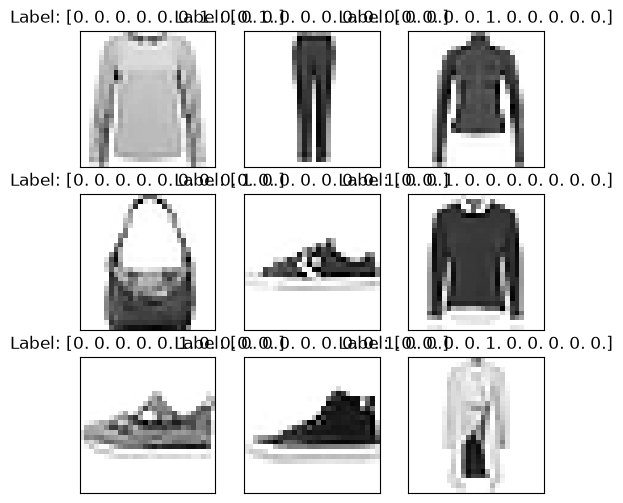

In [3]:
import matplotlib.pyplot as plt
import numpy as np
# Verify the data looks as expected

# Selecting 9 random indices
random_indices = np.random.choice(len(X_train), 9, replace=False)

# Creating a 3x3 grid plot
fig, axes = plt.subplots(3, 3, figsize=(6, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[random_indices[i]], cmap=plt.cm.gray_r, interpolation='nearest')
    ax.set_title(f"Label: {y_train[random_indices[i]]}")

    # Removing axis labels
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()


Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

**The data contains clothing items, which is expected. The quality of the images seems relatively low, so it may be difficult to different certain items e.g. tops and dresses

# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [5]:
from keras.models import Sequential
from keras.layers import Dense, Flatten

# Create a simple linear regression model
model = Sequential()
# You can use `model.add(<layer>)` to add layers to the model
model.add(Flatten(input_shape=(28,28)))
model.add(Dense(10))
model.summary()

# Compile the model using `model.compile()`

model.compile(
    loss='categorical_crossentropy', # Loss function
    optimizer='sgd', # Optimizer
    metrics=['accuracy'] # Metrics to evaluate the model
)

# Train the model with `model.fit()`

model.fit(
    X_train, # Training data
    y_train, # Training labels
    epochs=5, # Number of epochs
    batch_size=32, # Number of samples per batch
    validation_split=0.2 # Use 20% of the data for validation
)

# Evaluate the model with `model.evaluate()`

loss, accuracy = model.evaluate(X_test, y_test)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')


/Users/lisa/Documents/Classes & Workshops/MLF/deep_learning/deep-learning-env/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 567us/step - accuracy: 0.1260 - loss: 10.6665 - val_accuracy: 0.1254 - val_loss: 11.5314
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 487us/step - accuracy: 0.1310 - loss: 11.3100 - val_accuracy: 0.1297 - val_loss: 11.0765
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 473us/step - accuracy: 0.1617 - loss: 10.7422 - val_accuracy: 0.1743 - val_loss: 11.2472
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 523us/step - accuracy: 0.1848 - loss: 10.9178 - val_accuracy: 0.2128 - val_loss: 11.5825
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 478us/step - accuracy: 0.2179 - loss: 11.5811 - val_accuracy: 0.2175 - val_loss: 11.5564
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 386us/step - accuracy: 0.2203 - loss: 11.4578
Loss:     11.46
Accuracy: 22.03%


Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?

**The performance of the baseline model is quite poor, with less than 25% correct categorization. This seems to be much below what would be expected based on visualization, but likely reflects that a simple linear regression can't capture this kind of categorization

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [ ]:
from keras.layers import Conv2D

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model
model = Sequential()

model.add(Conv2D(filters=3, kernel_size=(5, 5), padding="same"))
model.add(Flatten())
model.add(Dense(64, activation='relu'))  # 64 neurons, ReLU activation
model.add(Dense(10, activation='softmax')) 

model.compile(
    loss='categorical_crossentropy', # Loss function
    optimizer='sgd', # Optimizer
    metrics=['accuracy'] # Metrics to evaluate the model
)

# Train the model

model.fit(
    X_train, # Training data
    y_train, # Training labels
    epochs=5, # Number of epochs
    batch_size=32, # Number of samples per batch
    validation_split=0.2 # Use 20% of the data for validation
)

# Evaluate the model

loss, accuracy = model.evaluate(X_test, y_test)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7744 - loss: 0.6481 - val_accuracy: 0.8257 - val_loss: 0.4863
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8425 - loss: 0.4449 - val_accuracy: 0.8459 - val_loss: 0.4305
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8582 - loss: 0.3999 - val_accuracy: 0.8602 - val_loss: 0.3925
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8684 - loss: 0.3718 - val_accuracy: 0.8668 - val_loss: 0.3790
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8747 - loss: 0.3500 - val_accuracy: 0.8705 - val_loss: 0.3706
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8626 - loss: 0.3883
Loss:     0.39
Accuracy: 86.26%


Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

**The model performed significantly better than the baseline model (about 64% better). I think the and the relu hidden layer I added both contributed to improving the model fit**

# 3. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.

In [13]:
import pandas as pd
# A. Test Hyperparameters

# Number of layers (testing with conv2d + relu, with up to 3 each)

num_layers = [1,2,3]

test_results = []

for conv in num_layers:
    for relu in num_layers:
        # Create CNN model
        model = Sequential()

        for num_conv in range(conv):
            model.add(Conv2D(filters=3, kernel_size=(5, 5), padding="same"))
        model.add(Flatten())
        for num_relu in range(relu):
            model.add(Dense(64, activation='relu'))  # 64 neurons, ReLU activation
        model.add(Dense(10, activation='softmax')) 

        model.compile(
            loss='categorical_crossentropy', # Loss function
            optimizer='sgd', # Optimizer
            metrics=['accuracy'] # Metrics to evaluate the model
        )

        # Train the model

        model.fit(
            X_train, # Training data
            y_train, # Training labels
            epochs=5, # Number of epochs
            batch_size=32, # Number of samples per batch
            validation_split=0.2 # Use 20% of the data for validation
        )

        # Evaluate the model

        loss, accuracy = model.evaluate(X_test, y_test)

        test_results.append(["N", conv,relu, loss, accuracy*100])

        print(f'Conv Layers:    {conv}')
        print(f'Relu Layers:    {relu}')
        print(f'Loss:     {loss:.2f}')
        print(f'Accuracy: {accuracy*100:.2f}%')

print(pd.DataFrame(test_results, columns=["Dropout", "Convolution Layers", "Relu Layers", "Loss", "Accuracy"]))
        

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7685 - loss: 0.6502 - val_accuracy: 0.8210 - val_loss: 0.4954
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8330 - loss: 0.4644 - val_accuracy: 0.8437 - val_loss: 0.4387
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8521 - loss: 0.4130 - val_accuracy: 0.8416 - val_loss: 0.4288
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8615 - loss: 0.3826 - val_accuracy: 0.8433 - val_loss: 0.4119
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8705 - loss: 0.3606 - val_accuracy: 0.8633 - val_loss: 0.3744
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8569 - loss: 0.4002
Conv Layers:    1
Relu Layers:    1
Loss:     0.40
Accuracy: 85.69%
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7443 - loss: 0.7025 - val_accuracy: 0.8154 - val_loss: 0.5086
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8295 - loss: 0.4

In [14]:
from keras.layers import Dropout

# B. Test presence or absence of regularization: Drop out after each layer
# This section tests with dropout, for a comparison to models with different hyperparameters, see above model

for conv in num_layers:
    for relu in num_layers:
        # Create CNN model
        model = Sequential()

        for num_conv in range(conv):
            model.add(Conv2D(filters=3, kernel_size=(5, 5), padding="same"))
            model.add(Dropout(0.3))
        model.add(Flatten())
        for num_relu in range(relu):
            model.add(Dense(64, activation='relu'))  # 64 neurons, ReLU activation
            model.add(Dropout(0.3))
        model.add(Dense(10, activation='softmax')) 

        model.compile(
            loss='categorical_crossentropy', # Loss function
            optimizer='sgd', # Optimizer
            metrics=['accuracy'] # Metrics to evaluate the model
        )

        # Train the model

        model.fit(
            X_train, # Training data
            y_train, # Training labels
            epochs=5, # Number of epochs
            batch_size=32, # Number of samples per batch
            validation_split=0.2 # Use 20% of the data for validation
        )

        # Evaluate the model

        loss, accuracy = model.evaluate(X_test, y_test)

        test_results.append(["Y", conv,relu, loss, accuracy*100])

        print(f'Conv Layers:    {conv}')
        print(f'Relu Layers:    {relu}')
        print(f'Loss:     {loss:.2f}')
        print(f'Accuracy: {accuracy*100:.2f}%')

print(pd.DataFrame(test_results, columns=["Dropout", "Convolution Layers", "Relu Layers", "Loss", "Accuracy"]))

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7206 - loss: 0.7922 - val_accuracy: 0.8283 - val_loss: 0.4792
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8075 - loss: 0.5409 - val_accuracy: 0.8433 - val_loss: 0.4336
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8220 - loss: 0.4949 - val_accuracy: 0.8512 - val_loss: 0.4100
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8330 - loss: 0.4683 - val_accuracy: 0.8569 - val_loss: 0.3933
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8397 - loss: 0.4497 - val_accuracy: 0.8593 - val_loss: 0.3882
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8524 - loss: 0.4068
Conv Layers:    1
Relu Layers:    1
Loss:     0.41
Accuracy: 85.24%
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6186 - loss: 1.0328 - val_accuracy: 0.7932 - val_loss: 0.5560
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7542 - loss: 0.6

Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

**The changes I made did not significantly improve model performance. Changing the number of layers was able to decrease loss and increase accuracy slightly while adding dropout fairly significantly decreased model performance. The best combination of hyperparameters and regularization, according to the model outputs is no dropout, 2 convergence layers and 2 relu layers**

# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

In [15]:
model = Sequential()

model.add(Conv2D(filters=3, kernel_size=(5, 5), padding="same"))
model.add(Conv2D(filters=3, kernel_size=(5, 5), padding="same"))
model.add(Flatten())
model.add(Dense(64, activation='relu'))  # 64 neurons, ReLU activation
model.add(Dense(64, activation='relu'))  # 64 neurons, ReLU activation
model.add(Dense(10, activation='softmax')) 

model.compile(
    loss='categorical_crossentropy', # Loss function
    optimizer='sgd', # Optimizer
    metrics=['accuracy'] # Metrics to evaluate the model
)

# Train the model

model.fit(
    X_train, # Training data
    y_train, # Training labels
    epochs=5, # Number of epochs
    batch_size=32, # Number of samples per batch
    validation_split=0.2 # Use 20% of the data for validation
)

# Evaluate the model

loss, accuracy = model.evaluate(X_test, y_test)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7839 - loss: 0.5973 - val_accuracy: 0.8378 - val_loss: 0.4510
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8532 - loss: 0.4077 - val_accuracy: 0.8571 - val_loss: 0.3952
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8675 - loss: 0.3675 - val_accuracy: 0.8484 - val_loss: 0.4148
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8765 - loss: 0.3422 - val_accuracy: 0.8744 - val_loss: 0.3549
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8831 - loss: 0.3248 - val_accuracy: 0.8751 - val_loss: 0.3495
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8651 - loss: 0.3761
Loss:     0.38
Accuracy: 86.51%


Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

**The final model is not a significant improvement from the CNN model with loss decreasing only 0.01 and accuracy by less than 0.5%. However, both models are a significant improvement on the baseline model. If I had more time, I would consider testing other regularization parameters, and the other hyperparameters (kernal size, padding, etc.) for hte Conv2D layers, in particular.**

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 26/10/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
    * The Lab 3 notebook (labs/lab_3.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.